<a href="https://colab.research.google.com/github/Tar-ive/dl_basics/blob/main/BackPropogation_%26_NN_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
# numpy is the only library we need to build this neural network

In [ ]:
# X = (hours sleeping , hours studying), y = test score of the student
X = np.array(([2,9], [1, 5], [3,6]), dtype= float)
y = np.array(([92], [86], [89]), dtype = float)

# we want the NN to predict y values between 0-1. which
# scale units
X = X/np.amax(X, axis=0) # maximum of the input array
y = y/100 # maximum test score is 100.

In [ ]:
X

array([[0.66666667, 1.        ],
       [0.33333333, 0.55555556],
       [1.        , 0.66666667]])

In [ ]:
y

array([[0.92],
       [0.86],
       [0.89]])

In [ ]:
class NeuralNetwork(object):
  def __init__(self): # constructor of NN class
  # parameters
    self.inputSize = 2
    self.outputSize = 1
    self.hiddenSize = 3

    # weights
    self.W1 = np.random.randn(self.inputSize, self.hiddenSize) # (3 x 2) weight matrix from input to hidden layer
    self.W2 = np.random.randn(self.hiddenSize, self.outputSize) # (3 x 1) weight matrix from hidden layer to output layer

  def feedForward(self, X):
    #forward propogation through the network
    self.z = np.dot(X, self.W1) # dot product of X(input) and first set of weights
    self.z2 = self.sigmoid(self.z) # activation layer
    self.z3 = np.dot(self.z2, self.W2) # dot product of hidden later (12) and second set of weights (3 x 1)
    output = self.sigmoid(self.z3)
    return output


  def sigmoid(self, s, deriv=False): # takes function and converts it into probability
    if deriv == True:
      return s * (1 - s)
    return 1/(1+np.exp(-s))

  def backprop(self, X, y, output):
    # backward propogate through the network
    # main intention of doing backprop is to calculate sum of square of errors and minimize it. error = desire - predict

    self.output_error = y - output # error (y from our training set) (output is value predicted by our network)
    # delta = multiply diff in output array with derivate of sigmoid
    self.output_delta = self.output_error * self.sigmoid(output, deriv=True)

    #output of hidden layer is output delta * transpose of 2nd weight matrix
    self.z2_error = self.output_delta.dot(self.W2.T) # z2 error : how much our hidden layer weights contribute to output error. # comming from chain rule of calculas.
    self.z2_delta = self.z2_error * self.sigmoid(self.z2, deriv= True) # applying derivate of sigmoid to z2 error.

    self.W1 += X.T.dot(self.z2_delta) # adjusting first set (input -> hidden) weights
    self.W2 = self.z2.dot(self.output_delta) #adjusting second set (hidden -> output) weights

  def train(self, X, y):
    output = self.feedForward(X)
    self.backprop(X, y, output)


NN = NeuralNetwork()

for i in range(10000):
  if i % 100 == 0:
    print("Loss:", str(np.mean(np.square(y- NN.feedForward(X)))))# trains a neural netowork 1000 times
  NN.train(X, y)

print("Input:", str(X))
print("Actual Output:", str(y))
print("Loss:", str(np.mean(np.square(y- NN.feedForward(X)))))
print("Predicted Output:", str(NN.feedForward(X)))


Loss: 0.31169719424793046
Loss: 0.10293429118968955
Loss: 0.08866176903091644
Loss: 0.08104753943176884
Loss: 0.07721536903170335
Loss: 0.07505393315504567
Loss: 0.07368944719917087
Loss: 0.07275218285889075
Loss: 0.07206771084544496
Loss: 0.07154471923118512
Loss: 0.07113115127642494
Loss: 0.07079523692052118
Loss: 0.07051649748755494
Loss: 0.07028113304841001
Loss: 0.07007949751373133
Loss: 0.0699046388462149
Loss: 0.06975141521694714
Loss: 0.06961593841812326
Loss: 0.06949521131028827
Loss: 0.06938688463245697
Loss: 0.06928908963841886
Loss: 0.06920032028267228
Loss: 0.0691193486052495
Loss: 0.06904516286136873
Loss: 0.06897692154794767
Loss: 0.06891391874238857
Loss: 0.06885555762333373
Loss: 0.06880132999754456
Loss: 0.0687508002956773
Loss: 0.06870359293461836
Loss: 0.06865938224501394
Loss: 0.06861788437404566
Loss: 0.06857885072405547
Loss: 0.06854206259620267
Loss: 0.06850732678757825
Loss: 0.06847447194866112
Loss: 0.0684433455515797
Loss: 0.06841381135243517
Loss: 0.06838574

Sentdex

In [ ]:
inputs = [1, 2, 3, 2.5]


weights = [[0.2, 0.8, -0.5, 1.0],
           [0.5, -0.91, 0.26, -0.5],
          [-0.26, -0.27, 0.17, 0.87]]

biases = [2, 3, 0.5]

layer_outputs = []
for neuron_weights, neuron_bias in zip(weights, biases): # combines 2 lists into lists of lists - element wise
  neuron_output = 0
  for n_input, weight in zip(inputs, neuron_weights):
    neuron_output +=n_input * weight
  neuron_output += neuron_bias
  layer_outputs.append(neuron_output)

print(layer_outputs)

[4.8, 1.21, 2.385]


In [ ]:
some_value = -0.5
weight = 0.7
bias = 0.7
print(some_value * weight)
print(some_value + bias)



-0.35
0.19999999999999996


Using Numpy Now

In [ ]:
inputs = [1, 2, 3, 2.5]


weights = [0.2, 0.8, -0.5, 1.0]

bias = 2
import numpy as np

output = np.dot(weights, inputs) + bias
print(output)

4.8


In [ ]:
inputs = [1, 2, 3, 2.5]


weights = [[0.2, 0.8, -0.5, 1.0],
           [0.5, -0.91, 0.26, -0.5],
          [-0.26, -0.27, 0.17, 0.87]]

biases = [2, 3, 0.5]

output = np.dot(weights, inputs) + biases
print(output)

[4.8   1.21  2.385]


Batches, Layers and Objects

In [ ]:
inputs = [[1, 2, 3, 2.5],
          [2.0, 5.0, -1.0, 2.0],
          [-1.5, 2.7, 3.3, -0.8]]# features from a single sample.

weights = [[0.2, 0.8, -0.5, 1.0],
           [0.5, -0.91, 0.26, -0.5],
            [-0.26, -0.27, 0.17, 0.87]]

biases = [2, 3, 0.5]


weights2 = [[0.1, -0.14, 0.5],
           [-0.5, 0.12, -0.33],
            [-0.44,0.73, -0.13]]

biases2 = [-1, 2, -0.5]

layer1_outputs = np.dot(inputs, np.array(weights).T) + biases
layer2_outputs = np.dot(layer1_outputs, np.array(weights2).T) + biases2

print(layer2_outputs)


[[ 0.5031  -1.04185 -2.03875]
 [ 0.2434  -2.7332  -5.7633 ]
 [-0.99314  1.41254 -0.35655]]


In [ ]:
X = [[1, 2, 3, 2.5],
     [2.0, 5.0, -1.0, 2.0],
     [-1.5, 2.7, 3.3, -0.8]]# features from a single sample.
np.random.seed(0)

class Layer_Dense:
  def __init__(self, n_inputs, n_neurons):
    self.weights = 0.10 * np.random.randn(n_inputs, n_neurons) # if we do this we dont need to do transpose in forward pass
    self.biases = np.zeros((1, n_neurons)) # needs to be tuple
  def forward(self, inputs):
    self.output = np.dot(inputs, self.weights) + self.biases

layer1 = Layer_Dense(4, 5)
layer2 = Layer_Dense(5, 2)

layer1.forward(X)
# print(layer1.output)
layer2.forward(layer1.output)
print(layer2.output)


[[ 0.148296   -0.08397602]
 [ 0.14100315 -0.01340469]
 [ 0.20124979 -0.07290616]]


Activation Functions

In [ ]:
!pip install nnfs

In [ ]:
!nnfs


Neural Networks from Scratch in Python Tool.

Basic usage:
nnfs command [parameter1 [parameter2]]

Detailed usage:
nnfs info | code video_part [destination]

Commands:
  info    Prints information about the book
  code    Creates a file containing the code of given video part
          in given location. Location is optional, example:
          nnfs code 2 nnfs/p02.py
          will create a file p02.py in a nnfs folder containing
          the code of part 2 of video tutorial
    


Dataset for Neural Network

In [ ]:
import numpy as np

# Copyright (c) 2015 Andrej Karpathy
# License: https://github.com/cs231n/cs231n.github.io/blob/master/LICENSE
# Source: https://cs231n.github.io/neural-networks-case-study/
def create_data(samples, classes):
    X = np.zeros((samples*classes, 2))
    y = np.zeros(samples*classes, dtype='uint8')
    for class_number in range(classes):
        ix = range(samples*class_number, samples*(class_number+1))
        r = np.linspace(0.0, 1, samples)
        t = np.linspace(class_number*4, (class_number+1)*4, samples) + np.random.randn(samples)*0.2
        X[ix] = np.c_[r*np.sin(t*2.5), r*np.cos(t*2.5)]
        y[ix] = class_number
    return X, y

In [ ]:
X

[[1, 2, 3, 2.5], [2.0, 5.0, -1.0, 2.0], [-1.5, 2.7, 3.3, -0.8]]

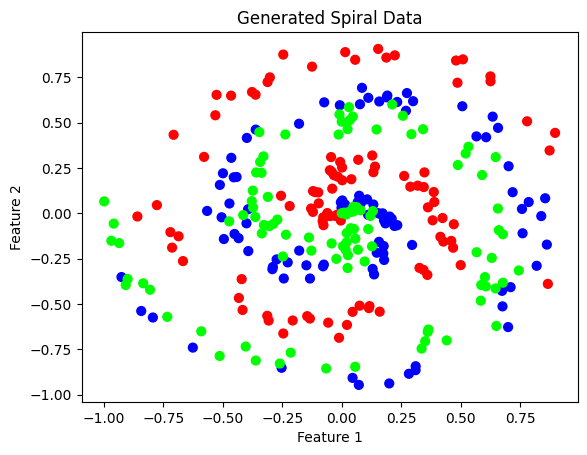

In [ ]:
import matplotlib.pyplot as plt

# Generate some sample data using the create_data function
# Assuming create_data is defined in a previous cell
X, y = create_data(samples=100, classes=3)

# Plot the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='brg')
plt.title('Generated Spiral Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data

nnfs.init()


class Layer_Dense:
  def __init__(self, n_inputs, n_neurons):
    self.weights = 0.10 * np.random.randn(n_inputs, n_neurons) # if we do this we dont need to do transpose in forward pass
    self.biases = np.zeros((1, n_neurons)) # needs to be tuple
  def forward(self, inputs):
    self.output = np.dot(inputs, self.weights) + self.biases

class Activation_ReLU:
  def forward(self, inputs):
    self.output = np.maximum(0, inputs)

class Activation_Softmax:
  def forward(self, inputs):
    exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) # so that we dont hit overflow value
    probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
    self.output = probabilities

class Loss:
  def calculate(self, output, y):
    sample_losses = self.forward(output, y)
    data_loss = np.mean(sample_losses)
    return data_loss

class Loss_CategoricalCrossentropy(Loss):
  def forward(self, y_pred, y_true):
    samples = len(y_pred)
    y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)
    if len(y_true.shape) == 1:
      correct_confidences = y_pred_clipped[range(samples), y_true]
    elif len(y_true.shape) == 2:
      correct_confidences = np.sum(y_pred_clipped * y_true, axis = 1)

    negative_log_likelihoods = -np.log(correct_confidences)
    return negative_log_likelihoods


X, y = spiral_data(samples = 100, classes = 3)

dense1 = Layer_Dense(2, 3)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(3,3)
activation2=Activation_Softmax()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

loss_function = Loss_CategoricalCrossentropy()
loss = loss_function.calculate(activation2.output, y)

print(loss)

print(activation2.output[:5])




1.098445
[[0.33333334 0.33333334 0.33333334]
 [0.33331734 0.3333183  0.33336434]
 [0.3332888  0.33329153 0.33341965]
 [0.33325943 0.33326396 0.33347666]
 [0.33323312 0.33323926 0.33352762]]


Exponentian function

In [ ]:
import math
layer_outputs = [4.8, 1.21, 2.385]

E = math.e
exp_values = []

for output in layer_outputs:
  exp_values.append(E**output)


[121.51041752   3.35348465  10.85906266]


Normalization

In [ ]:
import numpy as np
import nnfs
nnfs.init()
layer_outputs = [[4.8, 1.21, 2.385],
                 [8.9, -1.81, 0.2],
                 [1.41, 1.051, 0.026]]


exp_values = np.exp(layer_outputs)
norms_values = exp_values/ (np.sum(exp_values, axis=1, keepdims=True))

print(norms_values)

[[8.95282664e-01 2.47083068e-02 8.00090293e-02]
 [9.99811129e-01 2.23163963e-05 1.66554348e-04]
 [5.13097164e-01 3.58333899e-01 1.28568936e-01]]


Lograithm

In [ ]:
"""solving for x

e ** x = b"""

import numpy as np
import math
b= 5.2

print(np.log(b))

print(math.e ** 1.6486586255873816)

1.6486586255873816
5.199999999999999


Categorical Cross Entropy

In [ ]:
import math
softmax_output = [0.7, 0.1, 0.2]
target_output = [1, 0, 0]

loss = -(math.log(softmax_output[0]) * target_output[0] +
         math.log(softmax_output[1]) * target_output[1] +
         math.log(softmax_output[2]) * target_output[2])

print(loss)
loss = -math.log(softmax_output[0])
print(loss)

print(-math.log(0.7))
print(-math.log(0.5))

0.35667494393873245
0.35667494393873245
0.35667494393873245
0.6931471805599453


In [ ]:
import numpy as np

softmax_outputs = np.array([[0.7, 0.1, 0.2],
                   [0.1, 0.5, 0.4],
                   [0.02, 0.9, 0.08]])
class_targets = [0,1,1]
neg_log = (-np.log(softmax_outputs[range(len(softmax_outputs)), class_targets]))
average_loss = np.mean(neg_log)
print(average_loss)

0.38506088005216804
